In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
# plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

# Module 4. 模型擬合、評估與超參數調校

## 資料集欄位說明

本章使用 `ex4.csv`，內容是寶可夢資料。

| 欄位 | 說明 |
|---|---|
| Number | 寶可夢編號 |
| Name | 寶可夢名稱 |
| Type1 | 第一屬性 |
| Type2 | 第二屬性，若為空值代表沒有第二屬性 |
| HP, Attack, Defense, SpecialAtk, SpecialDef, Speed | 六個數值型能力值 |
| Generation | 世代 |
| Legendary | 是否為傳奇寶可夢 |

本章會新增兩個教學用欄位：

- `hasType2`：是否具有第二屬性，作為一般分類任務示範。
- `isLegendary`：是否為傳奇寶可夢，作為類別不平衡示範。

In [2]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("ex4.csv")

# 建立本章會用到的教學目標欄位
data["hasType2"] = data["Type2"].notna().astype(int)
data["isLegendary"] = data["Legendary"].astype(int)

feature_names = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

print("資料筆數與欄位數：")
print(data.shape)

print("前 5 筆資料：")
display(data.head())

print("數值型欄位的摘要統計：")
display(data[feature_names + ["Generation", "hasType2", "isLegendary"]].describe())

print("欄位型態與遺漏值狀況：")
display(data.info())

資料筆數與欄位數：
(894, 14)
前 5 筆資料：


,Number,Name,Type1,Type2,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation,Legendary,hasType2,isLegendary
0,1,妙蛙種子,Grass,Poison,45,49,49,65,65,45,1,False,1,0
1,2,妙蛙草,Grass,Poison,60,62,63,80,80,60,1,False,1,0
2,3,妙蛙花,Grass,Poison,80,82,83,100,100,80,1,False,1,0
3,3,妙蛙花Mega,Grass,Poison,80,100,123,122,120,80,1,False,1,0
4,4,小火龍,Fire,NaN,39,52,43,60,50,65,1,False,0,0


數值型欄位的摘要統計：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation,hasType2,isLegendary
count,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000
mean,69.469799,79.848993,74.420582,73.428412,72.401566,68.241611,3.710291,0.529083,0.088367
std,25.670988,32.691003,31.323902,33.110134,27.963359,29.283795,1.934529,0.499433,0.283987
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000,0.000000,0.000000
25%,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,2.000000,0.000000,0.000000
50%,66.000000,75.000000,70.000000,65.000000,70.000000,65.000000,4.000000,1.000000,0.000000
75%,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.000000,1.000000,0.000000
max,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,7.000000,1.000000,1.000000


欄位型態與遺漏值狀況：
<class 'pandas.DataFrame'>
RangeIndex: 894 entries, 0 to 893
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Number       894 non-null    int64
 1   Name         894 non-null    str  
 2   Type1        894 non-null    str  
 3   Type2        473 non-null    str  
 4   HP           894 non-null    int64
 5   Attack       894 non-null    int64
 6   Defense      894 non-null    int64
 7   SpecialAtk   894 non-null    int64
 8   SpecialDef   894 non-null    int64
 9   Speed        894 non-null    int64
 10  Generation   894 non-null    int64
 11  Legendary    894 non-null    bool 
 12  hasType2     894 non-null    int64
 13  isLegendary  894 non-null    int64
dtypes: bool(1), int64(10), str(3)
memory usage: 91.8 KB


None

## 1. 一般工作流程

這一格示範最基本的機器學習流程：

1. 選擇特徵與目標欄位。
2. 切分訓練資料與測試資料。
3. 對訓練資料做標準化。
4. 訓練模型。
5. 評估模型。
6. 放入新資料進行預測。

In [3]:
# ============================================================
# 1. 一般工作流程：不用 Pipeline，逐步完成
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

work_data = data.copy()

X = work_data[feature_names]
y = work_data["hasType2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

# 先用訓練資料 fit，再用同一個 scaler 轉換訓練資料與測試資料
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("測試資料 Accuracy：", accuracy_score(y_test, y_pred))
print("測試資料 F1-score：", f1_score(y_test, y_pred))

print("混淆矩陣：")
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[0, 1]),
    index=["實際沒有第二屬性", "實際有第二屬性"],
    columns=["預測沒有第二屬性", "預測有第二屬性"]
)
display(cm)

print("分類報告：")
print(classification_report(y_test, y_pred))

# 加入新資料進行預測
# 特徵順序必須和 feature_names 相同：
# HP, Attack, Defense, SpecialAtk, SpecialDef, Speed
newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]

newData_scaled = scaler.transform(newData)
new_pred = model.predict(newData_scaled)
new_prob = model.predict_proba(newData_scaled)

new_result = pd.DataFrame({
    "預測是否有第二屬性": new_pred,
    "沒有第二屬性的機率": new_prob[:, 0],
    "有第二屬性的機率": new_prob[:, 1]
})

print("新資料預測結果：")
display(new_result)

測試資料 Accuracy： 0.6071428571428571
測試資料 F1-score： 0.6333333333333333

混淆矩陣：


,預測沒有第二屬性,預測有第二屬性
實際沒有第二屬性,60,45
實際有第二屬性,43,76


分類報告：
              precision    recall  f1-score   support

           0       0.58      0.57      0.58       105
           1       0.63      0.64      0.63       119

    accuracy                           0.61       224
   macro avg       0.61      0.61      0.61       224
weighted avg       0.61      0.61      0.61       224

新資料預測結果：


,預測是否有第二屬性,沒有第二屬性的機率,有第二屬性的機率
0,0,0.572588,0.427412
1,1,0.031673,0.968327


## 2. Pipeline 與 ColumnTransformer

Pipeline 可以把「資料前處理」與「模型訓練」串成同一個流程。

ColumnTransformer 則適合處理不同型態的欄位，例如：

- 數值型欄位：能力值，可以做標準化與 ANOVA 特徵選擇。
- 類別型欄位：屬性、世代，可以做獨熱編碼與卡方特徵選擇。

這一格開始正式使用 Pipeline。

In [4]:
# ============================================================
# 2. Pipeline 與 ColumnTransformer
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2

pipe_data = data.copy()

numeric_features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]
categorical_features = ["Type1", "Generation"]

X = pipe_data[numeric_features + categorical_features]
y = pipe_data["hasType2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

numeric_preprocess = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=4))
])

categorical_preprocess = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ("select", SelectKBest(score_func=chi2, k=6))
])

preprocess = ColumnTransformer([
    ("numeric", numeric_preprocess, numeric_features),
    ("categorical", categorical_preprocess, categorical_features)
])

pipeline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

pipeline_model.fit(X_train, y_train)
y_pred = pipeline_model.predict(X_test)

print("Pipeline 測試資料 Accuracy：", accuracy_score(y_test, y_pred))
print("Pipeline 測試資料 F1-score：", f1_score(y_test, y_pred))
print("分類報告：")
print(classification_report(y_test, y_pred))

Pipeline 測試資料 Accuracy： 0.6651785714285714
Pipeline 測試資料 F1-score： 0.6781115879828327

分類報告：
              precision    recall  f1-score   support

           0       0.64      0.67      0.65       105
           1       0.69      0.66      0.68       119

    accuracy                           0.67       224
   macro avg       0.66      0.67      0.66       224
weighted avg       0.67      0.67      0.67       224



## 3. K-fold Cross Validation

交叉驗證可以避免只依賴單一次訓練/測試切分。

這裡使用 5-fold cross validation，並逐一印出每一折的訓練分數與驗證分數。

In [5]:
# ============================================================
# 3. K-fold cross validation：逐一檢查每一個 fold
# ============================================================

from sklearn.model_selection import StratifiedKFold

cv_data = data.copy()

X = cv_data[feature_names]
y = cv_data["hasType2"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

fold_rows = []
fold_number = 1

for train_index, valid_index in skf.split(X, y):
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]
    y_train_fold = y.iloc[train_index]
    y_valid_fold = y.iloc[valid_index]

    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
    ])

    fold_model.fit(X_train_fold, y_train_fold)

    train_pred = fold_model.predict(X_train_fold)
    valid_pred = fold_model.predict(X_valid_fold)

    row = {
        "fold": fold_number,
        "train_accuracy": accuracy_score(y_train_fold, train_pred),
        "valid_accuracy": accuracy_score(y_valid_fold, valid_pred),
        "train_f1": f1_score(y_train_fold, train_pred),
        "valid_f1": f1_score(y_valid_fold, valid_pred)
    }
    fold_rows.append(row)

    fold_number = fold_number + 1

fold_result = pd.DataFrame(fold_rows)

print("每一個 fold 的訓練與驗證結果：")
display(fold_result)

print("\n平均驗證 Accuracy：", fold_result["valid_accuracy"].mean())
print("平均驗證 F1-score：", fold_result["valid_f1"].mean())

每一個 fold 的訓練與驗證結果：


,fold,train_accuracy,valid_accuracy,train_f1,valid_f1
0,1,0.600000,0.541899,0.629534,0.590000
1,2,0.598601,0.592179,0.636248,0.647343
2,3,0.591608,0.597765,0.636816,0.640000
3,4,0.611189,0.536313,0.649874,0.582915
4,5,0.579609,0.617978,0.624220,0.660000



平均驗證 Accuracy： 0.5772267905341787
平均驗證 F1-score： 0.6240515136066808


## 4. 模型擬合、欠擬合與過擬合

- 欠擬合：模型太簡單，訓練資料與測試資料分數都不高。
- 過擬合：模型太複雜，訓練資料分數很高，但測試資料分數相對較差。
- 較理想：訓練分數與測試分數都不錯，而且差距不要太大。

這裡用決策樹深度示範模型複雜度的差異。

In [6]:
# ============================================================
# 4. 欠擬合與過擬合：用決策樹深度做示範
# ============================================================

from sklearn.tree import DecisionTreeClassifier

fit_data = data.copy()

X = fit_data[feature_names]
y = fit_data["hasType2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

tree_underfit = DecisionTreeClassifier(max_depth=1, random_state=0)
tree_underfit.fit(X_train, y_train)

tree_reasonable = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=0)
tree_reasonable.fit(X_train, y_train)

tree_overfit = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=0)
tree_overfit.fit(X_train, y_train)

rows = []

train_pred = tree_underfit.predict(X_train)
test_pred = tree_underfit.predict(X_test)
rows.append({
    "模型": "max_depth=1，容易欠擬合",
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred)
})

train_pred = tree_reasonable.predict(X_train)
test_pred = tree_reasonable.predict(X_test)
rows.append({
    "模型": "max_depth=3，較簡單且穩定",
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred)
})

train_pred = tree_overfit.predict(X_train)
test_pred = tree_overfit.predict(X_test)
rows.append({
    "模型": "max_depth=None，容易過擬合",
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred)
})

fit_result = pd.DataFrame(rows)
display(fit_result)

,模型,train_accuracy,test_accuracy
0,max_depth=1，容易欠擬合,0.605970,0.620536
1,max_depth=3，較簡單且穩定,0.640299,0.611607
2,max_depth=None，容易過擬合,0.995522,0.575893


## 5. 學習曲線與驗證曲線

- 學習曲線：觀察訓練資料量改變時，訓練分數與驗證分數如何變化。
- 驗證曲線：觀察某個超參數改變時，訓練分數與驗證分數如何變化。

In [7]:
# ============================================================
# 5. 計算學習曲線與驗證曲線
# ============================================================

from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

curve_data = data.copy()

X = curve_data[feature_names]
y = curve_data["hasType2"]

curve_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

train_sizes = np.linspace(0.2, 1.0, 5)

train_sizes_abs, train_scores, valid_scores = learning_curve(
    curve_model,
    X,
    y,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy"
)

learning_summary = pd.DataFrame({
    "train_size": train_sizes_abs,
    "train_score_mean": train_scores.mean(axis=1),
    "valid_score_mean": valid_scores.mean(axis=1),
    "train_score_std": train_scores.std(axis=1),
    "valid_score_std": valid_scores.std(axis=1)
})

C_values = np.array([0.01, 0.1, 1, 10, 100])

train_scores_v, valid_scores_v = validation_curve(
    curve_model,
    X,
    y,
    param_name="model__C",
    param_range=C_values,
    cv=cv,
    scoring="accuracy"
)

validation_summary = pd.DataFrame({
    "C": C_values,
    "train_score_mean": train_scores_v.mean(axis=1),
    "valid_score_mean": valid_scores_v.mean(axis=1),
    "train_score_std": train_scores_v.std(axis=1),
    "valid_score_std": valid_scores_v.std(axis=1)
})

print("學習曲線摘要：")
display(learning_summary)

print("\n驗證曲線摘要：")
display(validation_summary)

學習曲線摘要：


,train_size,train_score_mean,valid_score_mean,train_score_std,valid_score_std
0,143,0.636364,0.539169,0.019278,0.025275
1,286,0.594406,0.558207,0.009639,0.044305
2,429,0.586480,0.582838,0.018566,0.033303
3,572,0.579021,0.575017,0.013333,0.038501
4,715,0.595524,0.577227,0.011513,0.032336



驗證曲線摘要：


,C,train_score_mean,valid_score_mean,train_score_std,valid_score_std
0,0.01,0.585853,0.583931,0.006075,0.022956
1,0.10,0.593403,0.578350,0.007047,0.033797
2,1.00,0.596202,0.577227,0.010404,0.032336
3,10.00,0.595642,0.578344,0.009751,0.033113
4,100.00,0.595642,0.578344,0.009670,0.033113


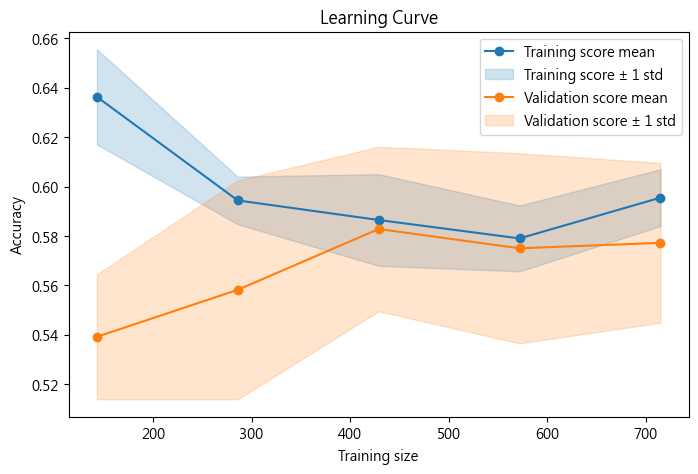

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


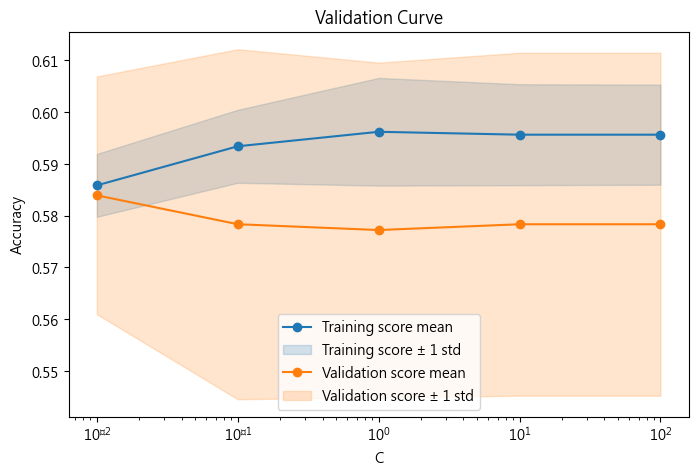

In [8]:
# ============================================================
# 5. 視覺化學習曲線與驗證曲線
# ============================================================
# 重點：
#   learning_curve 和 validation_curve 會在每一個設定下做多折交叉驗證。
#   所以每一個點不是只有一個分數，而是會有多個 fold 的分數。
#
#   這裡的折線代表平均分數 mean。
#   陰影區域代表 mean ± 1 standard deviation。
#
#   標準差越大，代表不同 fold 之間的結果差異越大，
#   也就是模型表現比較不穩定。
# ============================================================

# ------------------------------------------------------------
# 5.1 學習曲線：訓練資料量 vs 分數
# ------------------------------------------------------------
learning_x = learning_summary["train_size"].to_numpy()

learning_train_mean = learning_summary["train_score_mean"].to_numpy()
learning_train_std = learning_summary["train_score_std"].to_numpy()
learning_train_lower = np.clip(learning_train_mean - learning_train_std, 0, 1)
learning_train_upper = np.clip(learning_train_mean + learning_train_std, 0, 1)

learning_valid_mean = learning_summary["valid_score_mean"].to_numpy()
learning_valid_std = learning_summary["valid_score_std"].to_numpy()
learning_valid_lower = np.clip(learning_valid_mean - learning_valid_std, 0, 1)
learning_valid_upper = np.clip(learning_valid_mean + learning_valid_std, 0, 1)

plt.figure(figsize=(8, 5))

train_line = plt.plot(
    learning_x,
    learning_train_mean,
    marker="o",
    label="Training score mean"
)[0]
plt.fill_between(
    learning_x,
    learning_train_lower,
    learning_train_upper,
    alpha=0.2,
    color=train_line.get_color(),
    label="Training score ± 1 std"
)

valid_line = plt.plot(
    learning_x,
    learning_valid_mean,
    marker="o",
    label="Validation score mean"
)[0]
plt.fill_between(
    learning_x,
    learning_valid_lower,
    learning_valid_upper,
    alpha=0.2,
    color=valid_line.get_color(),
    label="Validation score ± 1 std"
)

plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
# plt.ylim(0, 1.05)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 5.2 驗證曲線：超參數 C vs 分數
# ------------------------------------------------------------
validation_x = validation_summary["C"].to_numpy()

validation_train_mean = validation_summary["train_score_mean"].to_numpy()
validation_train_std = validation_summary["train_score_std"].to_numpy()
validation_train_lower = np.clip(validation_train_mean - validation_train_std, 0, 1)
validation_train_upper = np.clip(validation_train_mean + validation_train_std, 0, 1)

validation_valid_mean = validation_summary["valid_score_mean"].to_numpy()
validation_valid_std = validation_summary["valid_score_std"].to_numpy()
validation_valid_lower = np.clip(validation_valid_mean - validation_valid_std, 0, 1)
validation_valid_upper = np.clip(validation_valid_mean + validation_valid_std, 0, 1)

plt.figure(figsize=(8, 5))

train_line = plt.semilogx(
    validation_x,
    validation_train_mean,
    marker="o",
    label="Training score mean"
)[0]
plt.fill_between(
    validation_x,
    validation_train_lower,
    validation_train_upper,
    alpha=0.2,
    color=train_line.get_color(),
    label="Training score ± 1 std"
)

valid_line = plt.semilogx(
    validation_x,
    validation_valid_mean,
    marker="o",
    label="Validation score mean"
)[0]
plt.fill_between(
    validation_x,
    validation_valid_lower,
    validation_valid_upper,
    alpha=0.2,
    color=valid_line.get_color(),
    label="Validation score ± 1 std"
)

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Validation Curve")
# plt.ylim(0, 1.05)
plt.legend()
plt.show()

## 6. P-R 曲線與 ROC 曲線

P-R 曲線與 ROC 曲線都會使用模型輸出的機率或分數。

這裡改用 `isLegendary` 作為目標，因為傳奇寶可夢是少數類別，較適合示範 P-R 曲線與類別不平衡問題。

Average Precision： 0.6984683013794916
ROC-AUC： 0.9230392156862745


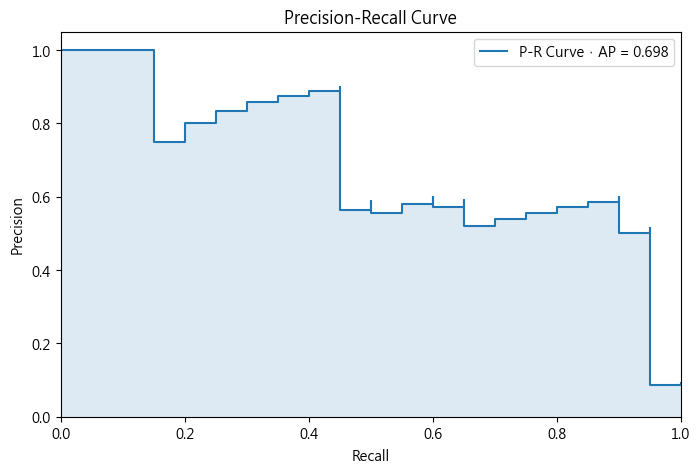

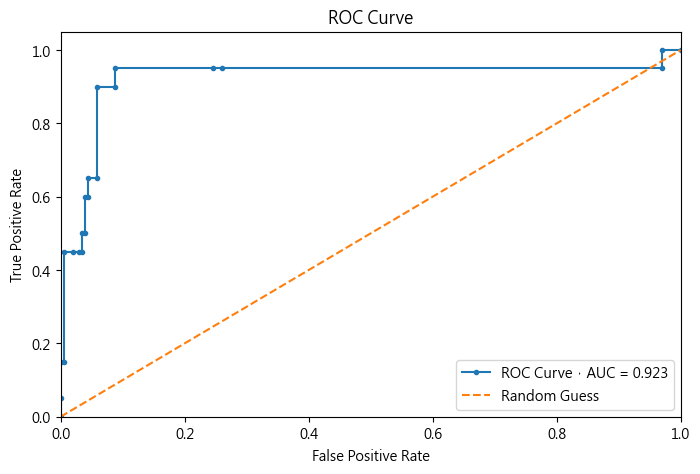

In [9]:
# ============================================================
# 6. P-R 曲線與 ROC 曲線
# ============================================================

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# 6.1 準備資料
# ------------------------------------------------------------

pr_data = data.copy()

X = pr_data[feature_names]
y = pr_data["isLegendary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

# ------------------------------------------------------------
# 6.2 建立 Pipeline：標準化 + 邏輯斯回歸
# ------------------------------------------------------------

pr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

pr_model.fit(X_train, y_train)

# ------------------------------------------------------------
# 6.3 取得模型對「正類」的預測機率
# ------------------------------------------------------------
# predict_proba(X_test)[:, 1] 代表模型預測為正類的機率
# 在這裡，正類是 isLegendary = 1

positive_score = pr_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 6.4 計算 P-R 曲線與 ROC 曲線需要的資料
# ------------------------------------------------------------

precision, recall, pr_thresholds = precision_recall_curve(y_test, positive_score)
fpr, tpr, roc_thresholds = roc_curve(y_test, positive_score)

average_precision = average_precision_score(y_test, positive_score)
roc_auc = roc_auc_score(y_test, positive_score)

print("Average Precision：", average_precision)
print("ROC-AUC：", roc_auc)

# ------------------------------------------------------------
# 6.5 繪製 P-R 曲線
# ------------------------------------------------------------
# precision_recall_curve() 回傳的 recall 通常是由大到小排列
# 為了讓圖形從左到右呈現 Recall 由 0 到 1，
# 這裡將 recall 與 precision 反轉

recall_plot = recall[::-1]
precision_plot = precision[::-1]

plt.figure(figsize=(8, 5))

# 畫出 P-R 曲線
plt.step(
    recall_plot,
    precision_plot,
    where="post",
    label=f"P-R Curve，AP = {average_precision:.3f}"
)

# 將 P-R 曲線下面的面積填上淡淡的顏色
plt.fill_between(
    recall_plot,
    precision_plot,
    0,
    step="post",
    alpha=0.15
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 6.6 繪製 ROC 曲線
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    marker=".",
    label=f"ROC Curve，AUC = {roc_auc:.3f}"
)

# 隨機猜測的基準線
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## 7. 超參數調校

這一格示範 Module 4 提到的幾種調參方式：

- GridSearchCV：把指定組合全部測試。
- RandomizedSearchCV：從候選範圍中抽幾組測試。
- LogisticRegressionCV：模型內建的交叉驗證版本。
- Nested Cross-Validation：外層評估泛化能力，內層負責調參。

這裡使用對數尺度的 `C` 候選值，因為正規化強度常常需要跨數量級搜尋。

In [10]:
# ============================================================
# 7. 超參數調校：GridSearchCV、RandomizedSearchCV、內建 CV、Nested CV
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegressionCV

tune_data = data.copy()

X = tune_data[feature_names]
y = tune_data["hasType2"]

# 建立一個 Pipeline，裡面包含標準化與邏輯斯回歸模型。
search_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=0))
])

# 這裡的 inner_cv 是用來在 GridSearchCV 和 RandomizedSearchCV 裡面做交叉驗證的。
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

# outer_cv 是用來在 Nested CV 裡面做交叉驗證的。
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

# GridSearchCV 會在 param_grid 定義的每一組參數設定下，使用 inner_cv 做交叉驗證，
# 計算每一組參數設定的平均 F1 分數，並找出平均 F1 分數最高的參數設定。
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2", "l1"],
    "model__solver": ["lbfgs", "liblinear"]
}
grid_search = GridSearchCV(
    search_model,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="f1"
)
grid_search.fit(X, y)

# RandomizedSearchCV 會在 param_random 定義的參數分布中，隨機抽取 n_iter 組參數設定，
# 使用 inner_cv 做交叉驗證，計算每一組參數設定的平均 F1 分數，並找出平均 F1 分數最高的參數設定。
param_random = {
    "model__C": np.logspace(-3, 2, 6),
    "model__penalty": ["l2", "l1"],
    "model__solver": ["lbfgs", "liblinear"]
}
random_search = RandomizedSearchCV(
    search_model,
    param_distributions=param_random,
    n_iter=4,
    cv=inner_cv,
    scoring="f1",
    random_state=0
)
random_search.fit(X, y)

# LogisticRegressionCV 是邏輯斯回歸模型內建的交叉驗證功能，可以直接在 fit 的過程中進行交叉驗證，
# 找出最佳的 C 參數設定。
scaler_for_cv = StandardScaler()
X_scaled = scaler_for_cv.fit_transform(X)
logistic_cv = LogisticRegressionCV(
    Cs=10,
    cv=inner_cv,
    scoring="f1",
    max_iter=1000,
    random_state=0
)
logistic_cv.fit(X_scaled, y)

# Nested CV 的流程是：在每一個 outer fold 的訓練資料上，使用 GridSearchCV 進行超參數調校，
# 找出最佳的參數設定，然後在 outer fold 的驗證資料上評估這個最佳參數設定的分數。
nested_search = GridSearchCV(
    search_model,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="f1"
)
nested_scores = cross_val_score(
    nested_search,
    X,
    y,
    cv=outer_cv,
    scoring="f1"
)

# 最後將這四種方法的重點結果整理成一個表格，方便比較。
tuning_result = pd.DataFrame({
    "方法": [
        "GridSearchCV",
        "RandomizedSearchCV",
        "LogisticRegressionCV",
        "Nested CV"
    ],
    "最佳或平均 F1": [
        grid_search.best_score_,
        random_search.best_score_,
        logistic_cv.scores_[1].mean(),
        nested_scores.mean()
    ],
    "重點結果": [
        str(grid_search.best_params_),
        str(random_search.best_params_),
        "best C = " + str(logistic_cv.C_[0]),
        "outer fold scores = " + str(nested_scores)
    ]
})

display(tuning_result)

,方法,最佳或平均 F1,重點結果
0,GridSearchCV,0.674294,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
1,RandomizedSearchCV,0.617247,"{'model__solver': 'liblinear', 'model__penalty..."
2,LogisticRegressionCV,0.635209,best C = 0.0001
3,Nested CV,0.675513,outer fold scores = [0.68329177 0.67164179 0.6...


## 8. 類別不平衡

類別不平衡時，不能只看 accuracy。這裡使用 `isLegendary` 示範，因為傳奇寶可夢是少數類別。

這一格比較：

1. baseline 模型。
2. `class_weight="balanced"`。
3. 上採樣：重複抽少數類別。
4. 下採樣：減少多數類別。

觀察重點是少數類別的 precision、recall、F1-score。

In [11]:
# ============================================================
# 8. 類別不平衡：class_weight、SMOTE 上採樣、TomekLinks / ENN 下採樣
# ============================================================
# 這一格示範類別不平衡資料常見的處理方式。
#
# 重點：
#   1. baseline：完全不處理類別不平衡。
#   2. class_weight="balanced"：讓模型在訓練時提高少數類別的權重。
#   3. SMOTE：上採樣方法，會根據少數類別樣本產生「合成的新樣本」。
#   4. TomekLinks：下採樣 / 清理方法，會移除類別邊界附近容易混淆的樣本。
#   5. EditedNearestNeighbours：下採樣 / 清理方法，會根據近鄰結果移除不穩定樣本。
#
# 注意：
#   - SMOTE、TomekLinks、ENN 都只能套用在訓練資料。
#   - 測試資料不能做 sampling，否則會造成資料外洩，讓評估結果失真。
#   - 因為 SMOTE、TomekLinks、ENN 都和距離或近鄰有關，
#     所以這裡把 StandardScaler 放在 sampler 前面。
#   - sklearn 的 Pipeline 不能直接放 imblearn 的 sampler，
#     因此這裡使用 imblearn.pipeline.Pipeline。

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours

imbalance_data = data.copy()

X = imbalance_data[feature_names]
y = imbalance_data["isLegendary"]

print("原始類別分布：")
display(y.value_counts().rename(index={0: "非傳奇", 1: "傳奇"}))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

print("訓練資料類別分布：")
display(y_train.value_counts().rename(index={0: "非傳奇", 1: "傳奇"}))

print("測試資料類別分布：")
display(y_test.value_counts().rename(index={0: "非傳奇", 1: "傳奇"}))

# 定義一個函式，訓練模型並回傳評估指標。
def evaluate_binary_model(model_name, model, X_train_input, y_train_input, X_test_input, y_test_input):
    """
    訓練二元分類模型，並回傳常用評估指標。

    這裡特別觀察「傳奇」這個少數類別的 precision、recall、F1-score。
    在類別不平衡問題中，accuracy 通常不夠可靠，
    因為模型只要大量預測成多數類別，也可能得到看似不錯的 accuracy。
    """
    model.fit(X_train_input, y_train_input)
    pred = model.predict(X_test_input)

    result = {
        "方法": model_name,
        "accuracy": accuracy_score(y_test_input, pred),
        "precision_傳奇": precision_score(y_test_input, pred, zero_division=0),
        "recall_傳奇": recall_score(y_test_input, pred, zero_division=0),
        "f1_傳奇": f1_score(y_test_input, pred, zero_division=0)
    }

    return result

# 定義一個函式，套用 sampler 後觀察訓練資料的類別分布。
def summarize_resampled_distribution(method_name, sampler):
    """
    顯示 sampler 套用在訓練資料後的類別分布。

    這個函式只是為了教學觀察類別分布變化。
    真正訓練模型時，仍然會透過 ImbPipeline 讓 sampler 只作用在訓練流程中。
    """
    preview_pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("sampler", sampler)
    ])

    X_resampled, y_resampled = preview_pipeline.fit_resample(X_train, y_train)
    class_counts = pd.Series(y_resampled).value_counts().sort_index()

    summary = {
        "方法": method_name,
        "非傳奇數量": class_counts.get(0, 0),
        "傳奇數量": class_counts.get(1, 0),
        "合計": len(y_resampled)
    }

    return summary


# ------------------------------------------------------------
# 建立不同處理方法的模型
# ------------------------------------------------------------
# baseline 和 class_weight 不需要 sampling，所以使用一般的 sklearn Pipeline 即可。
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

balanced_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=0))
])

# 只要 Pipeline 裡面包含 imblearn 的 sampler，就使用 ImbPipeline。
smote_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=0)),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

tomek_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", TomekLinks()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

enn_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", EditedNearestNeighbours()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])


# ------------------------------------------------------------
# 先觀察 sampling 後的訓練資料類別分布
# ------------------------------------------------------------
sampling_rows = []

sampling_rows.append({
    "方法": "原始訓練資料",
    "非傳奇數量": y_train.value_counts().get(0, 0),
    "傳奇數量": y_train.value_counts().get(1, 0),
    "合計": len(y_train)
})

sampling_rows.append(
    summarize_resampled_distribution("SMOTE 上採樣", SMOTE(random_state=0))
)

sampling_rows.append(
    summarize_resampled_distribution("TomekLinks 下採樣 / 邊界清理", TomekLinks())
)

sampling_rows.append(
    summarize_resampled_distribution("EditedNearestNeighbours 下採樣 / 近鄰清理", EditedNearestNeighbours())
)

print("不同 sampling 方法處理後的訓練資料類別分布：")
sampling_result = pd.DataFrame(sampling_rows)
display(sampling_result)


# ------------------------------------------------------------
# 評估不同方法的模型表現
# ------------------------------------------------------------
imbalance_rows = []

imbalance_rows.append(
    evaluate_binary_model("baseline", baseline_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("class_weight='balanced'", balanced_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("SMOTE 上採樣", smote_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("TomekLinks 下採樣 / 邊界清理", tomek_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("EditedNearestNeighbours 下採樣 / 近鄰清理", enn_model, X_train, y_train, X_test, y_test)
)

print("不同方法的模型評估結果：")
imbalance_result = pd.DataFrame(imbalance_rows)
display(imbalance_result)

原始類別分布：


isLegendary
非傳奇    815
傳奇      79
Name: count, dtype: int64

訓練資料類別分布：


isLegendary
非傳奇    611
傳奇      59
Name: count, dtype: int64

測試資料類別分布：


isLegendary
非傳奇    204
傳奇      20
Name: count, dtype: int64

不同 sampling 方法處理後的訓練資料類別分布：


,方法,非傳奇數量,傳奇數量,合計
0,原始訓練資料,611,59,670
1,SMOTE 上採樣,611,611,1222
2,TomekLinks 下採樣 / 邊界清理,603,59,662
3,EditedNearestNeighbours 下採樣 / 近鄰清理,559,59,618


不同方法的模型評估結果：


,方法,accuracy,precision_傳奇,recall_傳奇,f1_傳奇
0,baseline,0.946429,0.900000,0.45,0.600000
1,class_weight='balanced',0.910714,0.500000,0.95,0.655172
2,SMOTE 上採樣,0.928571,0.558824,0.95,0.703704
3,TomekLinks 下採樣 / 邊界清理,0.946429,0.900000,0.45,0.600000
4,EditedNearestNeighbours 下採樣 / 近鄰清理,0.924107,0.565217,0.65,0.604651
